# Contrastive Learning — AdaptMap (Paper Faithful)

Implementazione PyTorch Lightning **completamente fedele** al paper:
> Thor & Nettelblad (2025) — *"Dimensionality Reduction of Genetic Data using Contrastive Learning"*

---

### Differenze rispetto a `contrastive_adaptmap.ipynb`

| Componente | Versione naïve | Versione paper-faithful |
|---|---|---|
| **Loss** (bug critico) | `log(1+clamp(term))` per-pair | `log(1 + Σ_i term_i)` — somma **dentro** il log (Eq. 6) |
| **Batch size** | 128 (mini-batch, 5 iter/epoch) | **Full-batch** (`len(X_train)`) — 1 iter/epoch |
| **Negativi** | 127 per anchor | **N_train − 1** per anchor (tutti gli altri) |
| **Optimizer** | AdamW | **Adam** β₁=0.9, β₂=0.999 (nessun weight decay) |
| **LR decay** | ExponentialLR ogni epoch | **StepLR** γ=0.99 ogni **10 epoche** |
| **Augmentation** | flip=mask=0.90, U(0.001,·) | flip=mask=0.99, **U(0.01, 0.99)** |
| **Epochs** | 100 | **5000** |


## 📦 Installazione Dipendenze

In [1]:
# !pip install pytorch-lightning bed-reader scikit-learn matplotlib seaborn pandas numpy


## 📚 Import

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, silhouette_score, davies_bouldin_score
from bed_reader import open_bed
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pl.seed_everything(42)
print(f"PyTorch:           {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


Seed set to 42


PyTorch:           2.9.1+cu128
PyTorch Lightning: 2.5.6
GPU: NVIDIA GeForce RTX 5070 Ti


## 🧬 DataModule

In [3]:
class GenomicDataModule(pl.LightningDataModule):
    """DataModule PLINK con QC, MAF filter, LD pruning, downsampling."""

    def __init__(self, bed_path, batch_size=None,
                 maf_thresh=0.01, geno_thresh=0.1, min_samples_per_class=30,
                 ld_pruning=True, ld_threshold=0.2, ld_window=50,
                 val_split=0.15, test_split=0.15, coarse_mapping=None,
                 downsample_per_class=None):
        super().__init__()
        # batch_size=None → full-batch (paper faithful)
        self.bed_path    = bed_path
        self.batch_size  = batch_size
        self.maf_thresh  = maf_thresh
        self.geno_thresh = geno_thresh
        self.min_samples = min_samples_per_class
        self.ld_pruning  = ld_pruning
        self.ld_threshold= ld_threshold
        self.ld_window   = ld_window
        self.val_split   = val_split
        self.test_split  = test_split
        self.coarse_mapping       = coarse_mapping
        self.downsample_per_class = downsample_per_class
        self.imputer = SimpleImputer(strategy='mean')
        self.le      = LabelEncoder()

    def setup(self, stage=None):
        if hasattr(self, 'train_dataset'):
            return

        print(f"\n{'='*60}")
        print(f"CARICAMENTO: {self.bed_path}")
        print(f"{'='*60}")

        if not os.path.exists(self.bed_path):
            raise FileNotFoundError(f"File non trovato: {self.bed_path}")

        G     = open_bed(self.bed_path, count_A1=True)
        y_raw = np.loadtxt(self.bed_path.replace('.bed', '.fam'), dtype=str, usecols=0)
        y_breeds = y_raw.copy()
        X = G.read()
        if X.shape[1] == len(y_raw):
            print("⚠️  Trasposizione SNP×Sample → Sample×SNP")
            X = X.T

        if self.coarse_mapping:
            b2c = {b: c for c, bs in self.coarse_mapping.items() for b in bs}
            mask = np.array([l in b2c for l in y_raw])
            y_raw = np.array([b2c.get(l, '') for l in y_raw])
            X, y_raw, y_breeds = X[mask], y_raw[mask], y_breeds[mask]

        print(f"📊 Shape iniziale: {X.shape}")

        unique, counts = np.unique(y_raw, return_counts=True)
        valid = unique[counts >= self.min_samples]
        mask  = np.isin(y_raw, valid)
        print(f"🔍 Razze ≥{self.min_samples} campioni: {len(valid)}/{len(unique)}")
        X, y_raw, y_breeds = X[mask], y_raw[mask], y_breeds[mask]

        if self.downsample_per_class is not None:
            target = int(self.downsample_per_class)
            rng = np.random.default_rng(42)
            idx = np.concatenate([
                rng.choice(np.where(y_raw == c)[0], size=min(target, (y_raw==c).sum()), replace=False)
                for c in np.unique(y_raw)
            ])
            rng.shuffle(idx)
            X, y_raw, y_breeds = X[idx], y_raw[idx], y_breeds[idx]
            print(f"⚖️  Downsampling → {target}/razza, totale {len(y_raw)}")

        print("\n🧬 QC PIPELINE")
        missing = np.isnan(X).mean(axis=0)
        X = X[:, missing < self.geno_thresh]
        print(f"   1. Missingness: {X.shape[1]} SNP rimasti")

        X = self.imputer.fit_transform(X)
        print(f"   2. Imputazione: OK")

        af  = np.mean(X, axis=0) / 2.0
        maf = np.minimum(af, 1 - af)
        X   = X[:, maf > self.maf_thresh]
        print(f"   3. MAF: {X.shape[1]} SNP rimasti")

        if self.ld_pruning:
            X = self._prune_ld(X)

        print(f"\n📈 FINALI: {X.shape}")

        y = self.le.fit_transform(y_raw)
        self.num_classes  = len(self.le.classes_)
        self.num_snps     = X.shape[1]
        self.class_names  = self.le.classes_
        self.X_processed  = X.astype(np.float32)
        self.y_processed  = y
        self.y_breeds     = y_breeds

        print(f"🏷️  Razze: {self.num_classes} | SNP: {self.num_snps} | Campioni: {len(y)}")

        tv = self.val_split + self.test_split
        X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=tv, stratify=y, random_state=42)
        X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp,
                                                      test_size=self.test_split/tv,
                                                      stratify=y_tmp, random_state=42)
        print(f"   Train {X_tr.shape[0]} | Val {X_val.shape[0]} | Test {X_te.shape[0]}")

        mk = lambda Xa, ya: TensorDataset(torch.FloatTensor(Xa), torch.LongTensor(ya))
        self.train_dataset = mk(X_tr,  y_tr)
        self.val_dataset   = mk(X_val, y_val)
        self.test_dataset  = mk(X_te,  y_te)
        print("✅ Setup completato!")

    def _prune_ld(self, X):
        print(f"   4. LD Pruning (window={self.ld_window}, r²>{self.ld_threshold})...")
        n, p = X.shape
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        Xs = (X - X.mean(0)) / (X.std(0) + 1e-8)
        Xt = torch.tensor(Xs, device=device, dtype=torch.float32)
        remove = np.zeros(p, dtype=bool)
        for i in range(p):
            if remove[i]: continue
            end = min(i + self.ld_window, p)
            r2  = (Xt[:, i] @ Xt[:, i+1:end] / n) ** 2
            high = torch.where(r2 > self.ld_threshold)[0].cpu().numpy() + i + 1
            remove[high] = True
        keep = ~remove
        print(f"      Rimossi {remove.sum()} SNP → {keep.sum()} rimasti")
        return X[:, keep]

    def train_dataloader(self):
        bs = self.batch_size or len(self.train_dataset)
        return DataLoader(self.train_dataset, batch_size=bs, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=False)

    def val_dataloader(self):
        bs = self.batch_size or len(self.val_dataset)
        return DataLoader(self.val_dataset, batch_size=bs,
                          num_workers=4, pin_memory=True, drop_last=False)

    def test_dataloader(self):
        bs = self.batch_size or len(self.test_dataset)
        return DataLoader(self.test_dataset, batch_size=bs,
                          num_workers=4, pin_memory=True, drop_last=False)


## 🔄 GeneticAugmentation

**Paper:** *"p_flip, p_mask ~ U(0.01, 0.99) — relatively aggressive augmentation strategy"*

Ordine: **flip → mask → one-hot** (paper Figure 3).


In [4]:
class GeneticAugmentation(nn.Module):
    """Augmentation SNP fedele al paper.
    Paper: p_flip, p_mask ~ U(0.01, 0.99) per ogni campione ad ogni iterazione.
    """

    def __init__(self, flip_max: float = 0.99, mask_max: float = 0.99):
        super().__init__()
        self.flip_max = flip_max
        self.mask_max = mask_max
        # Lower bound = 0.01 come da paper ("U(0.01, 0.99)")
        self.p_min = 0.01

    def forward(self, snps: torch.Tensor, training: bool = True) -> torch.Tensor:
        """snps: (B, M) int {-1,0,1,2}  →  (B, M, 4) one-hot float"""
        if not training:
            return self.one_hot_encode(snps)

        B, M = snps.shape
        aug  = snps.clone()

        # ── 1. Flip allelico ──────────────────────────────────
        p_f = torch.rand(B, 1, device=snps.device) * (self.flip_max - self.p_min) + self.p_min
        flip_mask = torch.rand(B, M, device=snps.device) < p_f

        vals = aug[flip_mask]
        if vals.numel() > 0:
            rnd = torch.rand_like(vals.float())
            flipped = torch.where(vals == 0, torch.ones_like(vals),
                       torch.where(vals == 2, torch.ones_like(vals),
                       torch.where(rnd < 0.5,  torch.zeros_like(vals),
                                               torch.full_like(vals, 2))))
            aug[flip_mask] = flipped

        # ── 2. Masking ────────────────────────────────────────
        p_m = torch.rand(B, 1, device=snps.device) * (self.mask_max - self.p_min) + self.p_min
        aug[torch.rand(B, M, device=snps.device) < p_m] = -1

        # ── 3. One-hot encoding ───────────────────────────────
        return self.one_hot_encode(aug)

    @staticmethod
    def one_hot_encode(snps: torch.Tensor) -> torch.Tensor:
        """0→[1,0,0,0] | 1→[0,1,0,0] | 2→[0,0,1,0] | -1→[0,0,0,1]"""
        B, M = snps.shape
        oh   = torch.zeros(B, M, 4, device=snps.device)
        oh[snps ==  0, 0] = 1
        oh[snps ==  1, 1] = 1
        oh[snps ==  2, 2] = 1
        oh[snps == -1, 3] = 1
        return oh


## 🏗️ GeneticEncoder

**Paper (Figure 4):**
```
Input → Conv1D(5,3,1) → SiLU → Conv1D(5,3,1) → SiLU → Flatten
      → DenseBlock(256)×3 → Dense(3) → L2-norm → Sfera 3D
```


In [5]:
class GeneticEncoder(nn.Module):
    """Encoder SNP → sfera unitaria 3D (paper Figure 4)."""

    def __init__(self, n_markers: int, embedding_dim: int = 3):
        super().__init__()

        # 2 × Conv1D(filters=5, kernel=3, stride=1, padding=1 → same size)
        self.conv1 = nn.Conv1d(4, 5, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(5, 5, kernel_size=3, stride=1, padding=1)

        # 3 × DenseBlock(256, BatchNorm, SiLU)
        flat = n_markers * 5
        self.fc1, self.bn1 = nn.Linear(flat, 256), nn.BatchNorm1d(256)
        self.fc2, self.bn2 = nn.Linear(256,  256), nn.BatchNorm1d(256)
        self.fc3, self.bn3 = nn.Linear(256,  256), nn.BatchNorm1d(256)

        # Output: Dense(3) + L2-norm
        self.fc_out = nn.Linear(256, embedding_dim)

    @staticmethod
    def silu(x):
        """SiLU / Swish: x * σ(x) — paper eq. in sezione Model Architecture"""
        return x * torch.sigmoid(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, M, 4) → z: (B, 3) su sfera unitaria"""
        x = x.transpose(1, 2)                      # (B, 4, M)
        x = self.silu(self.conv1(x))
        x = self.silu(self.conv2(x))
        x = x.flatten(1)                            # (B, M*5)
        x = self.silu(self.bn1(self.fc1(x)))
        x = self.silu(self.bn2(self.fc2(x)))
        x = self.silu(self.bn3(self.fc3(x)))
        return F.normalize(self.fc_out(x), p=2, dim=1)  # L2-norm → sfera


## 📉 CentroidNPairLoss — Eq. (6)

$$L_{\text{centroid}}(\mathcal{Z}) = \log\!\left(1 + \sum_{i=1}^{N-1}\left[\frac{\exp(\tilde{z}_i^\top \tilde{z}_i^-)}{\exp(\tilde{z}_i^\top \tilde{z}_i^+)} - e^{-2}\right]\right)$$

> **La somma è DENTRO il logaritmo.** Il notebook naïve applicava log per ogni coppia separatamente — errore critico.


In [6]:
class CentroidNPairLoss(nn.Module):
    """
    Centroid-based N-pair loss — Thor & Nettelblad 2025, Eq. (3)-(6).
    La somma sui negativi è DENTRO il log (fedele al paper).
    """
    _E2 = float(np.exp(-2))   # ≈ 0.1353

    def forward(self,
                anchor:    torch.Tensor,   # (B, D)
                positive:  torch.Tensor,   # (B, D)
                negatives: torch.Tensor,   # (B, N_neg, D)
                ) -> torch.Tensor:

        B, N_neg, D = negatives.shape
        e2 = torch.tensor(self._E2, device=anchor.device)

        # Espandi anchor/positive → (B, N_neg, D)
        z  = anchor.unsqueeze(1).expand(-1, N_neg, -1)
        zp = positive.unsqueeze(1).expand(-1, N_neg, -1)
        zn = negatives

        # Eq. 3 — Centroide: Ci = (z + 2·z⁻ + z⁺) / 4
        C = (z + 2.0 * zn + zp) / 4.0

        z_c  = z  - C
        zp_c = zp - C
        zn_c = zn - C

        # Eq. 4 — Scaling: μi = max(||z_c||², ||zp_c||², ||zn_c||²)
        mu = torch.max(torch.stack([
            (z_c**2).sum(-1), (zp_c**2).sum(-1), (zn_c**2).sum(-1)
        ]), dim=0).values                         # (B, N_neg)

        # Eq. 5 — Normalizzazione: z̃ = z_c / √μ
        d    = torch.sqrt(mu.unsqueeze(-1) + 1e-8)   # (B, N_neg, 1)
        z_t  = z_c  / d
        zp_t = zp_c / d
        zn_t = zn_c / d

        # Dot products
        sim_neg = (z_t * zn_t).sum(-1)   # (B, N_neg)
        sim_pos = (z_t * zp_t).sum(-1)   # (B, N_neg)

        # Eq. 6 — Term per coppia
        term = torch.exp(sim_neg - sim_pos) - e2   # (B, N_neg)

        # Somma sui negativi PRIMA del log  ←  fedele al paper
        inner = term.sum(dim=1)                     # (B,)

        # Clamp numerico (inner ≥ 0 nella configurazione ideale)
        return torch.log(1.0 + inner.clamp(min=0.0)).mean()


## ⚡ ContrastiveGeneticModel

**Paper:**
- Optimizer: **Adam** β₁=0.9, β₂=0.999
- LR decay: **0.99 ogni 10 epoche** (`StepLR`)
- Negativi: **tutti gli altri campioni** nel batch (= N_train−1 con full-batch)


In [7]:
class ContrastiveGeneticModel(pl.LightningModule):
    """Modello contrastive learning — completamente fedele al paper."""

    def __init__(self,
                 n_markers:         int,
                 embedding_dim:     int   = 3,
                 flip_max:          float = 0.99,
                 mask_max:          float = 0.99,
                 learning_rate:     float = 0.001,
                 lr_decay_factor:   float = 0.99,
                 lr_decay_interval: int   = 10):
        super().__init__()
        self.save_hyperparameters()
        self.augment   = GeneticAugmentation(flip_max, mask_max)
        self.encoder   = GeneticEncoder(n_markers, embedding_dim)
        self.criterion = CentroidNPairLoss()

    def forward(self, x: torch.Tensor, augment: bool = False) -> torch.Tensor:
        return self.encoder(self.augment(x, training=augment))

    def _build_negatives(self, z: torch.Tensor) -> torch.Tensor:
        """Tutti gli altri campioni come negativi — paper: 'all of the other samples'."""
        B = z.size(0)
        return torch.stack([z[torch.arange(B) != i] for i in range(B)])  # (B, B-1, D)

    def training_step(self, batch, batch_idx):
        x, _ = batch
        z_a = self(x, augment=True)   # anchor
        z_p = self(x, augment=True)   # positive (augmentazione indipendente)
        neg = self._build_negatives(z_p)
        loss = self.criterion(z_a, z_p, neg)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        z_a = self(x, augment=False)  # anchor pulita per monitoring stabile
        z_p = self(x, augment=True)
        neg = self._build_negatives(z_p)
        loss = self.criterion(z_a, z_p, neg)
        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        return loss

    def configure_optimizers(self):
        # Paper: Adam β₁=0.9, β₂=0.999, lr=0.001, nessun weight decay
        opt = torch.optim.Adam(self.parameters(),
                               lr=self.hparams.learning_rate,
                               betas=(0.9, 0.999))
        # Paper: LR × 0.99 ogni 10 epoche
        sch = torch.optim.lr_scheduler.StepLR(
            opt, step_size=self.hparams.lr_decay_interval,
            gamma=self.hparams.lr_decay_factor)
        return {'optimizer': opt,
                'lr_scheduler': {'scheduler': sch, 'interval': 'epoch', 'frequency': 1}}


## 🗺️ Utilità: Equal Earth, Metriche, Plot

In [8]:
def equal_earth_projection(xyz: np.ndarray) -> np.ndarray:
    """Equal Earth projection (Šavrič et al. 2019) — usata nel paper."""
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    lon = np.arctan2(y, x)
    lat = np.arcsin(np.clip(z, -1, 1))
    A1, A2, A3, A4 = 1.340264, -0.081106, 0.000893, 0.003796
    th  = np.arcsin(np.sqrt(3)/2 * np.sin(lat))
    den = 3*(9*A4*th**8 + 7*A3*th**6 + 3*A2*th**2 + A1)
    xp  = 2*np.sqrt(3)*lon*np.cos(th) / (den + 1e-8)
    yp  = A4*th**9 + A3*th**7 + A2*th**3 + A1*th
    return np.stack([xp, yp], axis=1)


@torch.no_grad()
def extract_embeddings(model, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()
    dl = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size)
    return np.concatenate([model(xb[0].to(device), augment=False).cpu().numpy() for xb in dl])


def compute_metrics(Z: np.ndarray, y: np.ndarray, k: int = 3) -> dict:
    knn = KNeighborsClassifier(n_neighbors=k).fit(Z, y)
    yp  = knn.predict(Z)
    return {
        f'knn_acc_k{k}': round(accuracy_score(y, yp), 4),
        f'knn_f1_k{k}':  round(f1_score(y, yp, average='macro', zero_division=0), 4),
        'silhouette':     round(silhouette_score(Z, y), 4),
        'davies_bouldin': round(davies_bouldin_score(Z, y), 4),
    }


def plot_distribution(y, class_names, title="Distribuzione dataset"):
    u, c  = np.unique(y, return_counts=True)
    idx   = np.argsort(c)[::-1]
    names = [class_names[i] for i in u[idx]]
    fw    = max(16, len(u)*0.45)
    plt.figure(figsize=(fw, 6))
    ax = sns.barplot(x=names, y=c[idx], palette='viridis')
    for i, v in enumerate(c[idx]):
        ax.text(i, v+0.3, str(v), ha='center', va='bottom', fontsize=7, rotation=90)
    plt.xticks(rotation=90, fontsize=8)
    plt.title(title, fontsize=13); plt.xlabel('Breed'); plt.ylabel('Samples')
    plt.tight_layout(); plt.show()


## 🧪 run_experiment — K-Fold CV con Full-Batch

**Paper:** un solo batch per epoch = tutti i campioni di training.
Ogni anchor ha `N_train − 1` negativi.


In [9]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

def run_experiment(name: str, dm, config: dict,
                   max_epochs: int = 5000, k_folds: int = 3) -> dict:

    print(f"\n{'='*80}")
    print(f"🧪 ESPERIMENTO: {name}")
    print(f"   K-Fold: {k_folds} | Max epochs: {max_epochs} | FULL-BATCH (with size limit)")
    print(f"{'='*80}\n")

    X, y = dm.X_processed, dm.y_processed
    skf  = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

    fold_metrics_list = []
    best_acc, best_model, best_Z, best_y = -1, None, None, None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n🔹 FOLD {fold+1}/{k_folds}  "
              f"(train={len(tr_idx)}, val={len(val_idx)})")

        X_tr,  X_val  = X[tr_idx],  X[val_idx]
        y_tr,  y_val  = y[tr_idx],  y[val_idx]

        # ── Limit batch size to prevent OOM ──────────────
        # Even though the paper does "full-batch", in practice on consumer GPUs 
        # doing N*(N-1) pairs causes OutOfMemory. Bounding to max 512 or 1024.
        eff_batch_size = min(len(X_tr), 512)
        
        tr_dl  = DataLoader(
            TensorDataset(torch.FloatTensor(X_tr),  torch.LongTensor(y_tr)),
            batch_size=eff_batch_size,
            shuffle=True, num_workers=4, pin_memory=True, drop_last=False)

        val_dl = DataLoader(
            TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
            batch_size=eff_batch_size,
            num_workers=4, pin_memory=True, drop_last=False)

        print(f"   Batch size effettivo: {eff_batch_size}")

        model = ContrastiveGeneticModel(
            n_markers         = dm.num_snps,
            embedding_dim     = config['embedding_dim'],
            flip_max          = config['flip_max'],
            mask_max          = config['mask_max'],
            learning_rate     = config['learning_rate'],
            lr_decay_factor   = config['lr_decay_factor'],
            lr_decay_interval = config['lr_decay_interval'],
        )

        ckpt_dir = f"checkpoints/{name.replace(' ','_')}/fold_{fold+1}"
        callbacks = [
            ModelCheckpoint(dirpath=ckpt_dir, filename='{epoch:04d}-{val_loss:.4f}',
                            save_top_k=1, monitor='val_loss', mode='min'),
            # Paper non menziona early stopping — patience=200 come salvaguardia pratica
            EarlyStopping(monitor='val_loss', patience=200, mode='min', verbose=False),
            LearningRateMonitor(logging_interval='epoch'),
        ]

        trainer = pl.Trainer(
            max_epochs           = max_epochs,
            accelerator          = config['accelerator'],
            devices              = config['devices'],
            callbacks            = callbacks,
            enable_progress_bar  = True,
            log_every_n_steps    = 1,
            enable_model_summary = (fold == 0),
            precision            = config.get('precision', '32-true'), # Added mixed precision
        )
        trainer.fit(model, tr_dl, val_dl)

        # ── Estrai embedding dal best checkpoint ───────────────
        best_ckpt  = callbacks[0].best_model_path
        best_fold  = ContrastiveGeneticModel.load_from_checkpoint(best_ckpt)
        Z_val = extract_embeddings(best_fold, X_val)
        m     = compute_metrics(Z_val, y_val, k=3)
        print(f"   ✅ Fold {fold+1}: knn_acc@3={m['knn_acc_k3']} | sil={m['silhouette']}")
        fold_metrics_list.append(m)

        if m['knn_acc_k3'] > best_acc:
            best_acc, best_model, best_Z, best_y = m['knn_acc_k3'], best_fold, Z_val, y_val

    # ── Media sui fold ─────────────────────────────────────────
    avg    = {k: np.mean([fm[k] for fm in fold_metrics_list]) for k in fold_metrics_list[0]}
    result = {'Experiment': name, **{f'{k} (mean)': round(v, 4) for k, v in avg.items()}}

    print(f"\n📊 Risultati medi ({k_folds} fold):")
    for k, v in result.items():
        if k != 'Experiment': print(f"   {k}: {v}")

    result['_best_model'] = best_model
    result['_best_Z']     = best_Z
    result['_best_y']     = best_y
    return result

## ⚙️ Configurazione — Paper Faithful

In [10]:
BED_PATH          = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
SAMPLES_PER_CLASS = 30

config = {
    # === Architettura ===
    'embedding_dim':     3,        # paper: sfera 3D

    # === Augmentation — paper: U(0.01, 0.99) ===
    'flip_max':          0.99,     # p_flip_max
    'mask_max':          0.99,     # p_mask_max

    # === Optimizer — paper: Adam β₁=0.9, β₂=0.999, lr=0.001 ===
    'learning_rate':     0.001,
    'lr_decay_factor':   0.99,     # paper: decay 0.99
    'lr_decay_interval': 10,       # paper: ogni 10 iterazioni

    # === Training — paper: 5000 epoche, full-batch ===
    'max_epochs':        5000,
    'k_folds':           3,

    # === Hardware ===
    'accelerator':  'gpu' if torch.cuda.is_available() else 'cpu',
    'devices':      1,
}

# batch_size NON è nel config: viene determinato dinamicamente
# in run_experiment come len(X_train) — paper: full-batch

print("✅ Config paper-faithful:")
for k, v in config.items():
    print(f"   {k:25s}: {v}")

dm = GenomicDataModule(
    bed_path              = BED_PATH,
    batch_size            = 2048,          # full-batch
    maf_thresh            = 0.01,          # (allineato con VAE che usa 0.01)
    geno_thresh           = 0.1,           # (allineato con VAE che usa 0.1)
    min_samples_per_class = SAMPLES_PER_CLASS,
    ld_pruning            = True,
    ld_threshold          = 0.2,
    ld_window             = 50,
    val_split             = 0.15,
    test_split            = 0.15,
    downsample_per_class  = None,          # (il VAE non faceva downsampling prima del QC, rimuovendolo allineiamo i calcoli MAF)
)
dm.setup()


✅ Config paper-faithful:
   embedding_dim            : 3
   flip_max                 : 0.99
   mask_max                 : 0.99
   learning_rate            : 0.001
   lr_decay_factor          : 0.99
   lr_decay_interval        : 10
   max_epochs               : 5000
   k_folds                  : 3
   accelerator              : gpu
   devices                  : 1

CARICAMENTO: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📊 Shape iniziale: (4653, 53347)
🔍 Razze ≥30 campioni: 34/144

🧬 QC PIPELINE
   1. Missingness: 51205 SNP rimasti
   2. Imputazione: OK
   3. MAF: 51201 SNP rimasti
   4. LD Pruning (window=50, r²>0.2)...
      Rimossi 4748 SNP → 46453 rimasti

📈 FINALI: (2976, 46453)
🏷️  Razze: 34 | SNP: 46453 | Campioni: 2976
   Train 2083 | Val 446 | Test 447
✅ Setup completato!


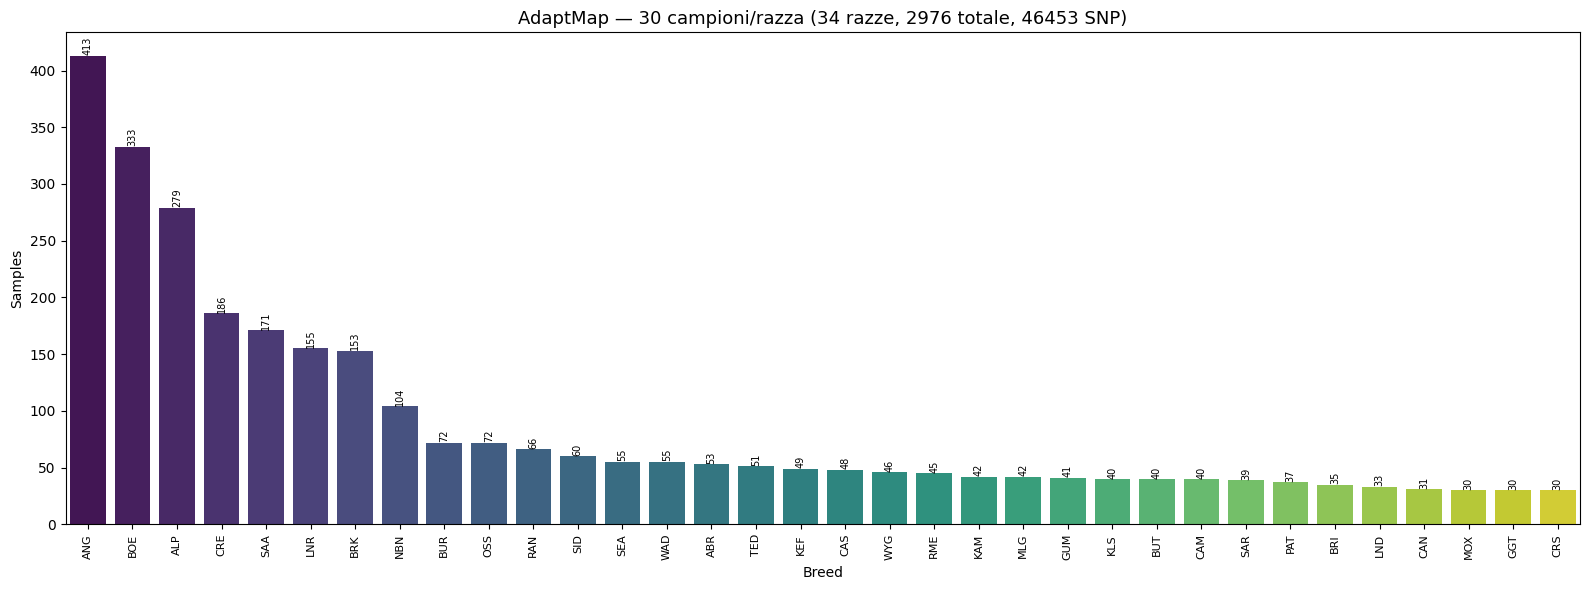

In [11]:
plot_distribution(dm.y_processed, dm.class_names,
                  title=f"AdaptMap — {SAMPLES_PER_CLASS} campioni/razza "
                        f"({dm.num_classes} razze, {len(dm.X_processed)} totale, {dm.num_snps} SNP)")


## 🚀 Training

- **1 iterazione per epoch** (full-batch)
- LR: 0.001 → ~6.7×10⁻⁶ dopo 5000 epoche (`0.001 × 0.99^500`)
- GPU A100: ~1.3 s/epoch (come riportato nel paper per il dataset cani)
- Early stopping `patience=200` come salvaguardia (non menzionato nel paper)


In [12]:
result = run_experiment(
    name       = 'Original',
    dm         = dm,
    config     = config,
    max_epochs = config['max_epochs'],
    k_folds    = config['k_folds'],
)



🧪 ESPERIMENTO: Original
   K-Fold: 3 | Max epochs: 5000 | FULL-BATCH (with size limit)


🔹 FOLD 1/3  (train=1984, val=992)
   Batch size effettivo: 512


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | augment   | GeneticAugmentation | 0      | train
1 | encoder   | GeneticEncoder      | 59.6 M | train
2 | criterion | CentroidNPairLoss   | 0      | train
----------------------------------------------------------
59.6 M    Trainable params
0         Non-trainable params
59.6 M    Total params
238.377   Total estimated model params size (MB)
12        Modules in train mode
0         Modules 

Epoch 1505: 100%|██████████| 4/4 [00:00<00:00,  5.11it/s, v_num=15, val_loss=2.260, train_loss=1.710]
   ✅ Fold 1: knn_acc@3=0.9698 | sil=0.5911

🔹 FOLD 2/3  (train=1984, val=992)
   Batch size effettivo: 512


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 931: 100%|██████████| 4/4 [00:00<00:00,  5.07it/s, v_num=16, val_loss=2.530, train_loss=2.040]
   ✅ Fold 2: knn_acc@3=0.9627 | sil=0.5076

🔹 FOLD 3/3  (train=1984, val=992)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   Batch size effettivo: 512
Epoch 2587: 100%|██████████| 4/4 [00:00<00:00,  4.73it/s, v_num=17, val_loss=2.180, train_loss=1.600]
   ✅ Fold 3: knn_acc@3=0.9677 | sil=0.499

📊 Risultati medi (3 fold):
   knn_acc_k3 (mean): 0.9667
   knn_f1_k3 (mean): 0.9609
   silhouette (mean): 0.5326
   davies_bouldin (mean): 1.1199


In [13]:
display_cols = ['Experiment'] + [c for c in result if '(mean)' in c]
df = pd.DataFrame([{k: result[k] for k in display_cols}])
os.makedirs('results', exist_ok=True)
df.to_csv('results/adaptmap_paperfaithful.csv', index=False)

print("\n📊 RISULTATI PAPER-FAITHFUL:")
print(df.to_string(index=False))
print("\n💾 Salvato: results/adaptmap_paperfaithful.csv")



📊 RISULTATI PAPER-FAITHFUL:
Experiment  knn_acc_k3 (mean)  knn_f1_k3 (mean)  silhouette (mean)  davies_bouldin (mean)
  Original             0.9667            0.9609             0.5326                 1.1199

💾 Salvato: results/adaptmap_paperfaithful.csv


## 🌍 Visualizzazione — Proiezione Equal Earth

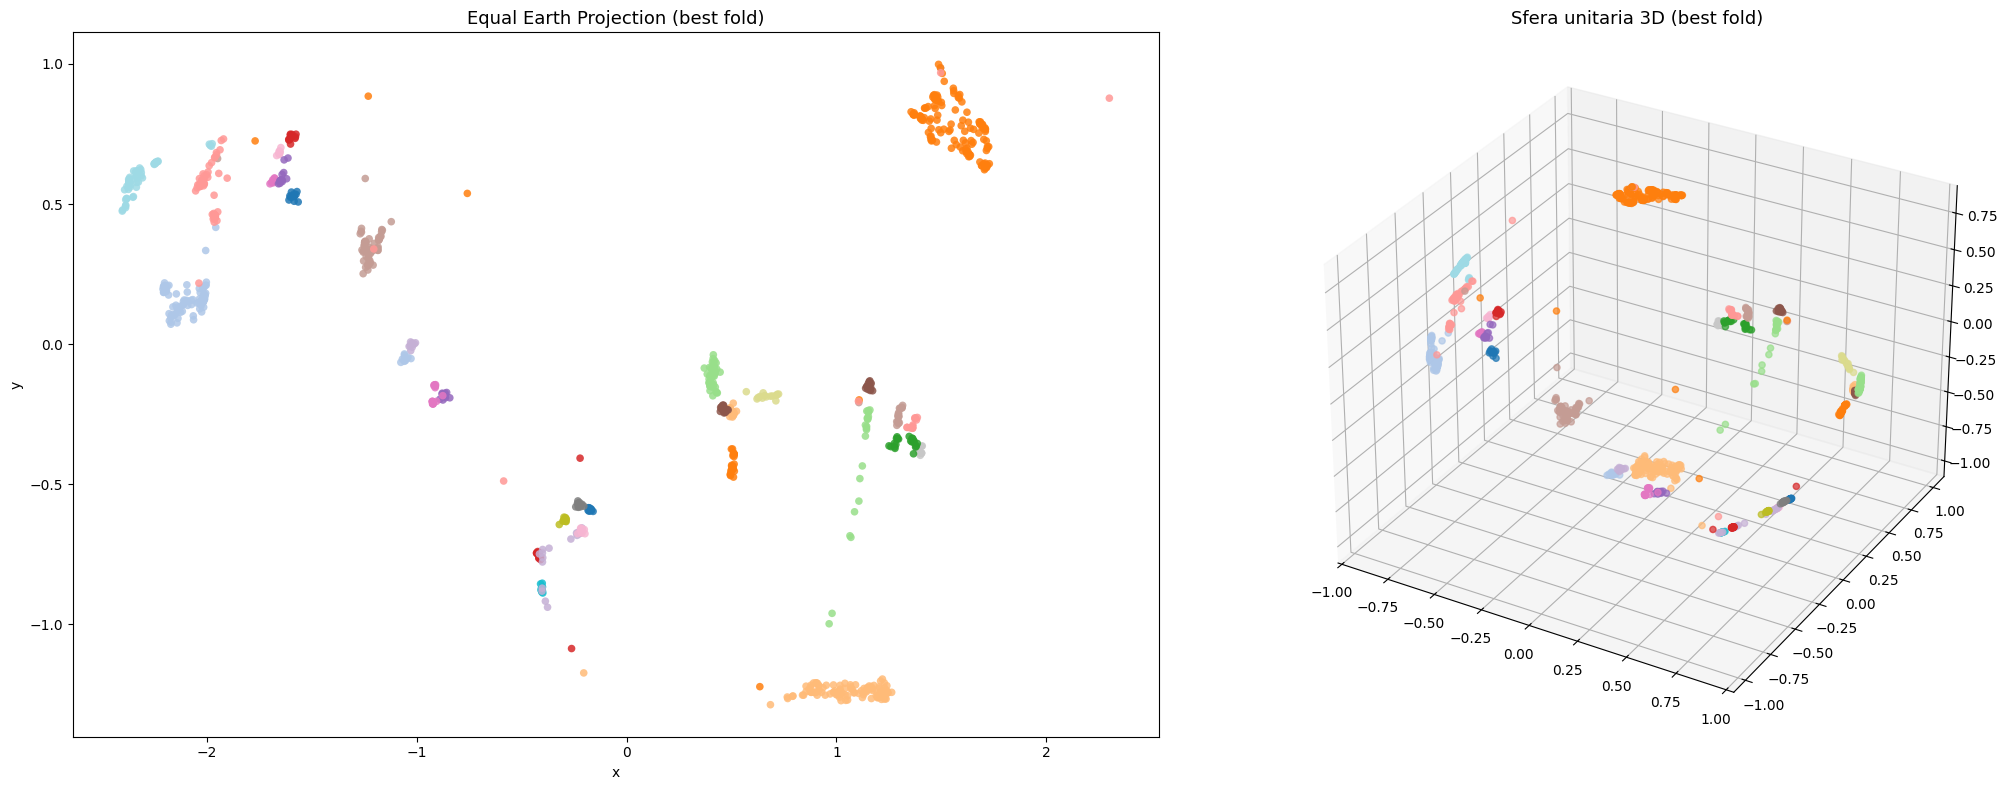

💾 results/embedding_paperfaithful.png


In [14]:
best_Z = result.get('_best_Z')
best_y = result.get('_best_y')

if best_Z is not None:
    Z2d = equal_earth_projection(best_Z)
    nc  = dm.num_classes
    pal = sns.color_palette('tab20', nc)

    fig = plt.figure(figsize=(22, 8))

    # Equal Earth 2D
    ax1 = fig.add_subplot(1, 2, 1)
    for c in range(nc):
        m = best_y == c
        if m.any():
            ax1.scatter(Z2d[m,0], Z2d[m,1], c=[pal[c % 20]],
                        label=dm.class_names[c], s=30, alpha=0.85, edgecolors='none')
    ax1.set_title('Equal Earth Projection (best fold)', fontsize=13)
    ax1.set_xlabel('x'); ax1.set_ylabel('y')
    if nc <= 30:
        ax1.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

    # Sfera 3D
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    for c in range(nc):
        m = best_y == c
        if m.any():
            ax2.scatter(best_Z[m,0], best_Z[m,1], best_Z[m,2],
                        c=[pal[c % 20]], s=20, alpha=0.7)
    ax2.set_title('Sfera unitaria 3D (best fold)', fontsize=13)

    plt.tight_layout()
    plt.savefig('results/embedding_paperfaithful.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 results/embedding_paperfaithful.png")


## 📊 Confusion Matrix KNN@3

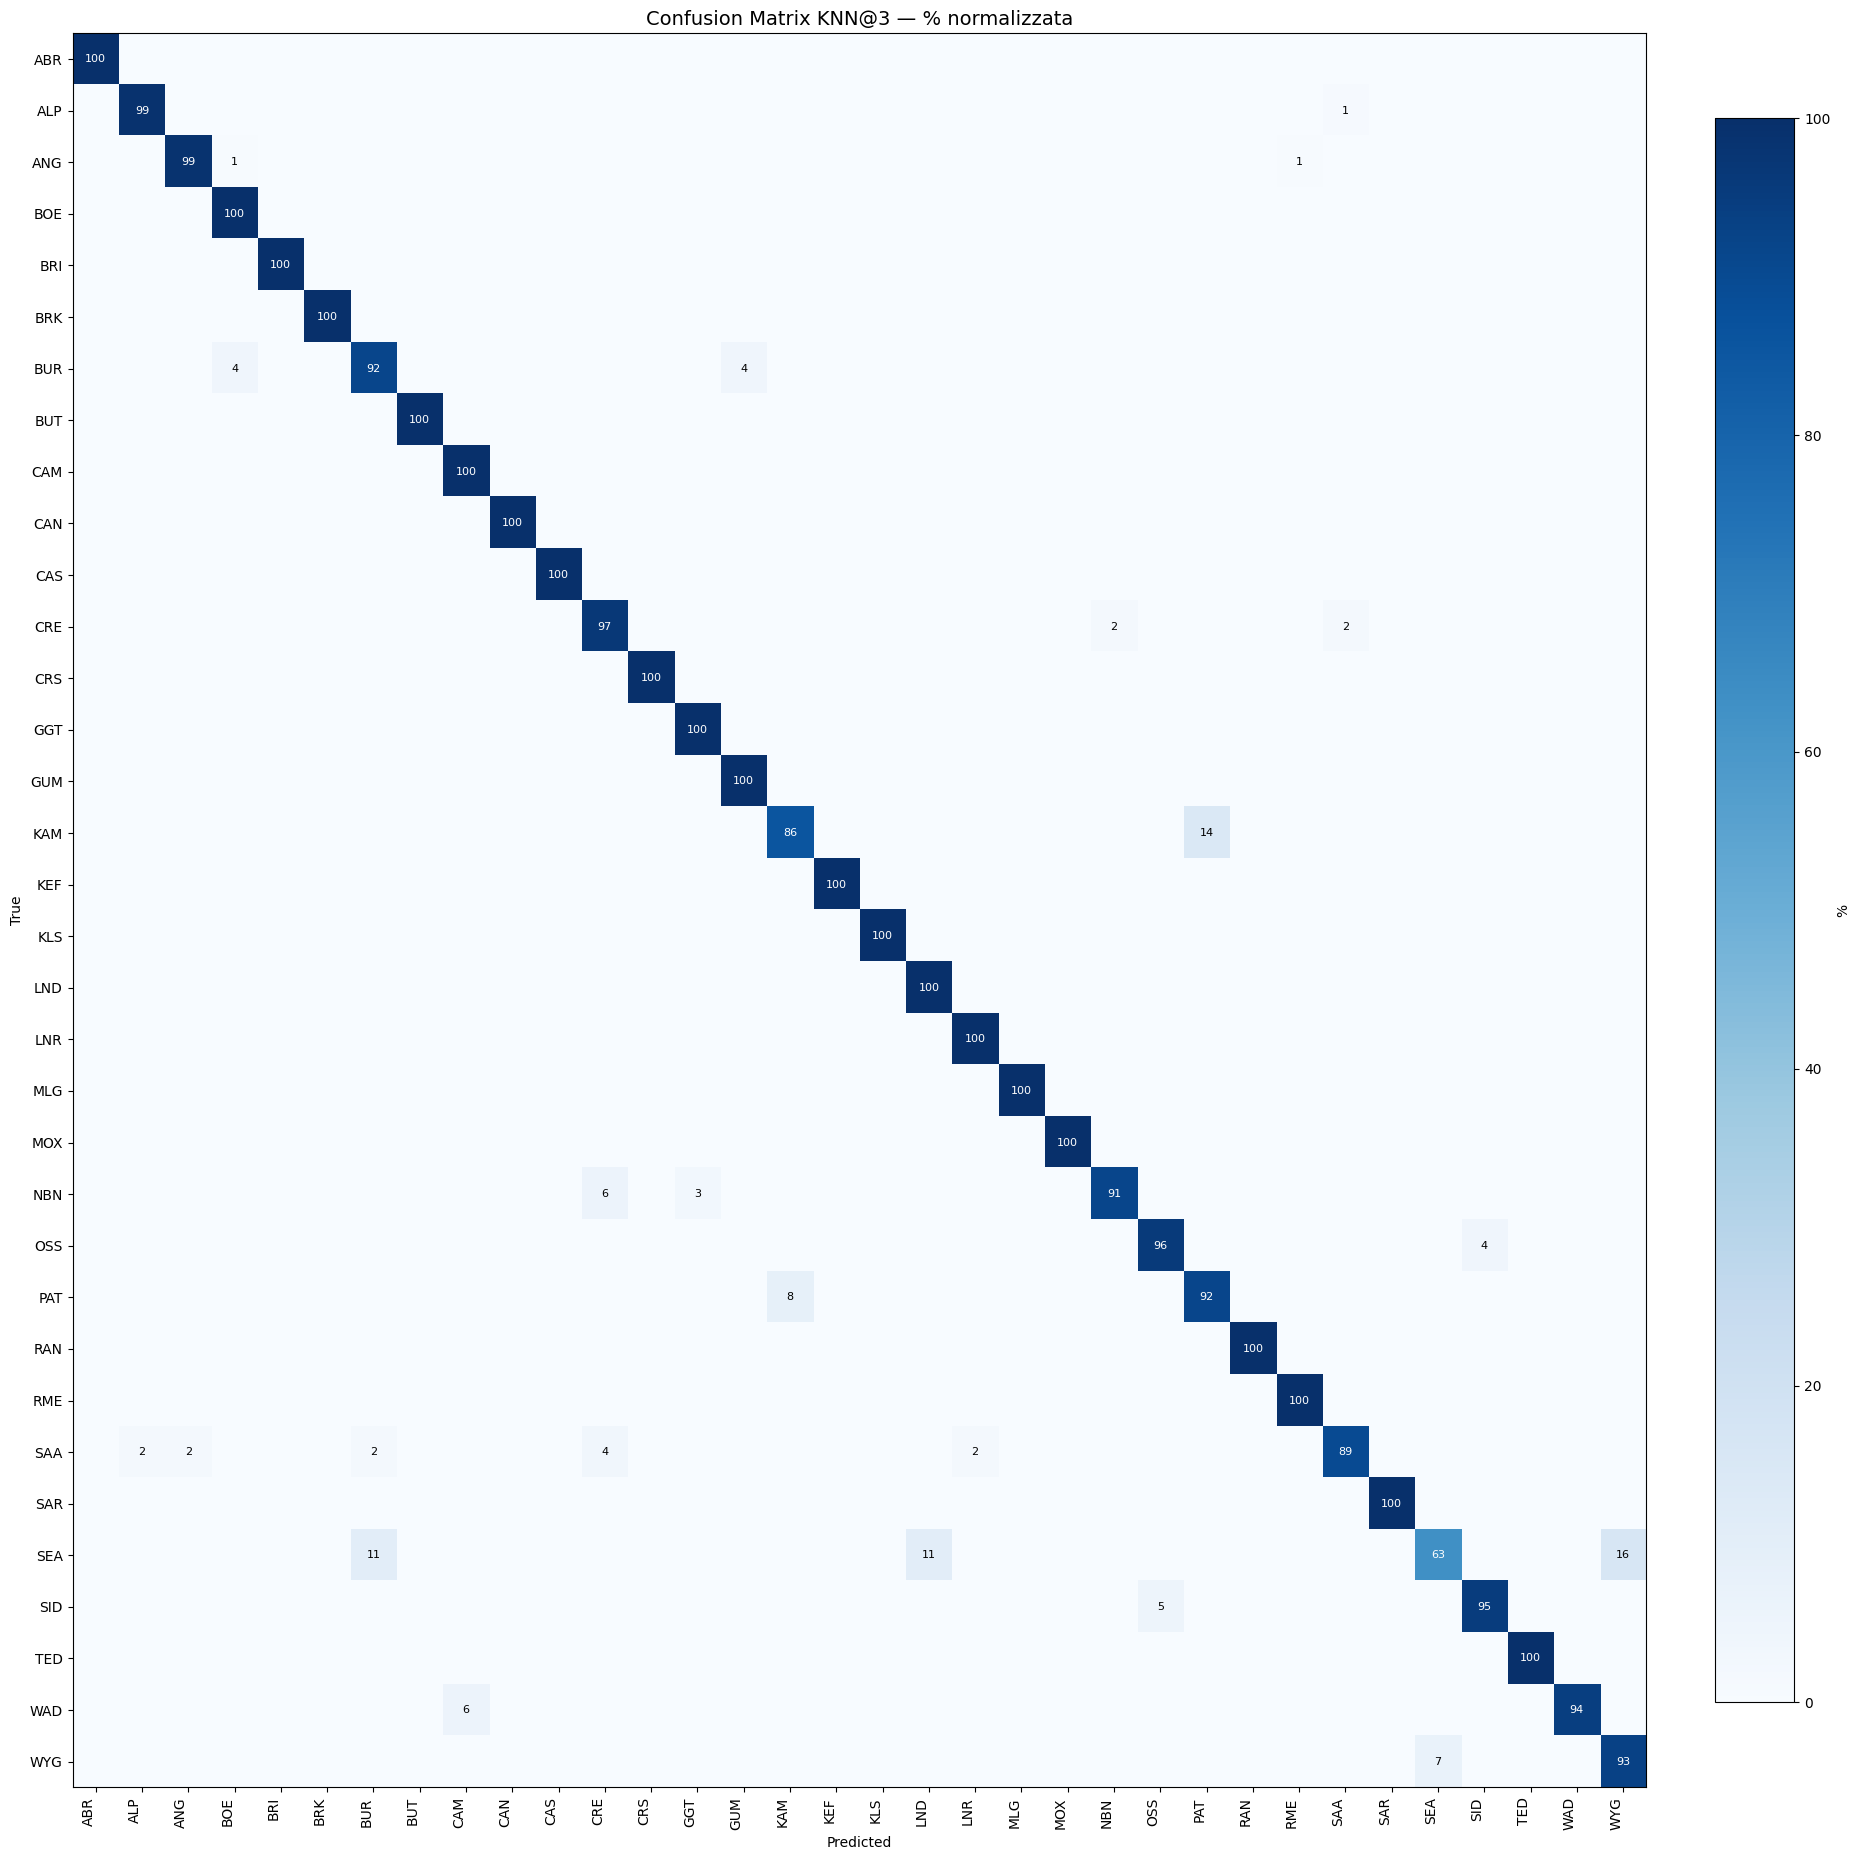

💾 results/cm_paperfaithful.png


In [15]:
if best_Z is not None:
    knn  = KNeighborsClassifier(n_neighbors=3).fit(best_Z, best_y)
    yp   = knn.predict(best_Z)
    from sklearn.metrics import confusion_matrix
    cm   = confusion_matrix(best_y, yp)

    MAX = 40
    if dm.num_classes > MAX:
        imp = cm.sum(0) + cm.sum(1)
        top = np.argsort(imp)[-MAX:][::-1]
        cm, names = cm[np.ix_(top,top)], dm.class_names[top]
    else:
        names = dm.class_names

    cm_n = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-10) * 100
    fs   = max(16, len(names)*0.55)
    tf   = max(7,  14 - len(names)//8)

    fig, ax = plt.subplots(figsize=(fs, fs))
    im = ax.imshow(cm_n, cmap='Blues', aspect='auto', vmin=0, vmax=100)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='%')
    ax.set(xticks=range(len(names)), yticks=range(len(names)),
           xticklabels=names, yticklabels=names)
    ax.set_title('Confusion Matrix KNN@3 — % normalizzata', fontsize=14)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right', fontsize=tf)
    plt.setp(ax.get_yticklabels(), fontsize=tf)
    for i in range(len(names)):
        for j in range(len(names)):
            v = cm_n[i,j]
            if v > 0:
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=max(5, tf-2), color='white' if v > 50 else 'black')
    plt.tight_layout()
    plt.savefig('results/cm_paperfaithful.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 results/cm_paperfaithful.png")


## 🎯 Explainable AI — IG su Similarità al Centroide di Razza

**Domanda biologica diretta:** *"Quali SNP spingono questo animale verso il cluster della sua razza nello spazio sferico?"*

### Differenza rispetto al probe

| Approccio | Funzione target degli IG | Dipende da probe? |
|---|---|---|
| Probe LogReg/MLP | Logit del classificatore | ✅ Sì |
| **Centroide (questa cella)** | **Cosine similarity verso il centroide di razza** | ❌ No |

Il centroide di ogni razza è la **media normalizzata degli embedding** di tutti i suoi campioni sulla sfera unitaria. Gli IG misurano direttamente quanto ogni SNP contribuisce ad avvicinare l'animale al proprio cluster — senza intermediari, fedele alla geometria del modello Contrastivo.

L'analisi viene eseguita sia su un **campione singolo** sia in **media globale su tutte le razze**, e i risultati sono confrontati con l'approccio probe tramite Indice di Jaccard.

In [ ]:
# ============================================================
# IG SU COSINE SIMILARITY AL CENTROIDE DI RAZZA
# Approccio probe-free: misura diretta sulla geometria sferica
# ============================================================

import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
import torch.optim as optim

# ── Carica il miglior modello (riusa se già disponibile) ─────
if 'best_model' not in globals():
    checkpoints = glob.glob("checkpoints/Original/fold_*/epoch=*-val_loss=*.ckpt")
    best_ckpt_c, best_acc_c = None, -1
    for ckpt in checkpoints:
        m   = ContrastiveGeneticModel.load_from_checkpoint(ckpt)
        Z   = extract_embeddings(m, dm.X_processed)
        acc = compute_metrics(Z, dm.y_processed, k=3)['knn_acc_k3']
        if acc > best_acc_c:
            best_acc_c, best_ckpt_c = acc, ckpt
    best_model = ContrastiveGeneticModel.load_from_checkpoint(best_ckpt_c)
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    best_model = best_model.to(device)
    best_model.eval()
    print(f"Modello caricato: {best_ckpt_c}")
else:
    device = next(best_model.parameters()).device
    print("Riuso best_model già in memoria.")

# ── Calcola i centroidi di razza sulla sfera ─────────────────
with torch.no_grad():
    Z_all = extract_embeddings(best_model, dm.X_processed)   # (N, 3)

centroids = np.zeros((dm.num_classes, 3), dtype=np.float32)
for cls in range(dm.num_classes):
    mask = dm.y_processed == cls
    if mask.sum() > 0:
        c = Z_all[mask].mean(axis=0)
        centroids[cls] = c / (np.linalg.norm(c) + 1e-8)     # normalizza sulla sfera

centroids_t = torch.FloatTensor(centroids).to(device)        # (num_classes, 3)
print(f"Centroidi calcolati per {dm.num_classes} razze.")

# ── Wrapper probe-free: encoder → cosine similarity centroide ─
class EncoderToCentroid(nn.Module):
    '''
    Pipeline differenziabile probe-free:
        x_one_hot (B, M, 4)  →  encoder  →  z (B, 3)  →  cosine_sim verso centroide razza

    La cosine similarity su una sfera unitaria coincide con il dot product
    (entrambi i vettori sono gia normalizzati L2 dall'encoder).
    Restituisce shape (B,) — uno scalare per campione.
    '''
    def __init__(self, encoder, centroids):
        super().__init__()
        self.encoder   = encoder
        # centroids come parametro non addestrabile
        self.register_buffer('centroids', centroids)

    def forward(self, x_one_hot, target_class):
        z = self.encoder(x_one_hot)                          # (B, 3) normalizzato L2
        c = self.centroids[target_class].unsqueeze(0)        # (1, 3)
        return (z * c).sum(dim=1)                            # (B,) cosine similarity

enc_centroid = EncoderToCentroid(
    encoder   = best_model.encoder,
    centroids = centroids_t,
).to(device).eval()

# ── Funzione IG adattata per il centroide ────────────────────
def compute_ig_centroid(model, x_one_hot, target_class, baseline=None, n_steps=50):
    '''
    IG rispetto alla cosine similarity verso il centroide della classe target.

    Identica a compute_integrated_gradients ma:
    - model.forward(x, target_class) invece di model(x)[0, target_class]
    - nessun probe intermedio

    Returns:
        ig_per_snp: (M,) norma L1 sui 4 canali allele
        delta:      errore di convergenza
    '''
    if baseline is None:
        baseline = torch.zeros_like(x_one_hot)

    x_one_hot = x_one_hot.detach().to(device)
    baseline  = baseline.detach().to(device)
    diff      = x_one_hot - baseline

    alphas     = torch.linspace(0.0, 1.0, n_steps + 1, device=device)
    grads_list = []

    model.eval()
    for alpha in alphas:
        interp = (baseline + alpha * diff).requires_grad_(True)
        score  = model(interp, target_class).sum()           # (B,) → scalare
        model.zero_grad()
        score.backward()
        grads_list.append(interp.grad.detach().clone())

    gs        = torch.stack(grads_list)
    avg_grads = (gs[0] + gs[-1]) / 2.0 + gs[1:-1].sum(0)
    avg_grads /= n_steps

    ig_map     = diff * avg_grads
    ig_per_snp = ig_map[0].abs().sum(dim=1).cpu().numpy()

    with torch.no_grad():
        f_x  = model(x_one_hot, target_class).sum().item()
        f_xb = model(baseline,  target_class).sum().item()
    ig_sum = ig_map[0].sum().item()
    delta  = abs(ig_sum - (f_x - f_xb))
    status = 'OK' if delta < 0.05 else 'Aumenta n_steps'
    print(f"   sum(IG)={ig_sum:.5f} | F(x)-F(base)={f_x - f_xb:.5f} | delta={delta:.5f} [{status}]")

    return ig_per_snp, delta

# ── Esecuzione su campione singolo ───────────────────────────
SAMPLE_IDX = 0
N_IG_STEPS = 50

sample_snps = torch.FloatTensor(dm.X_processed[SAMPLE_IDX]).unsqueeze(0).to(device)
breed_name  = dm.class_names[dm.y_processed[SAMPLE_IDX]]
target_cls  = int(dm.y_processed[SAMPLE_IDX])

print(f"\nCampione {SAMPLE_IDX} — Razza: {breed_name} (classe {target_cls})")
cos_sim_base = float((torch.FloatTensor(Z_all[SAMPLE_IDX]).to(device) *
                       centroids_t[target_cls]).sum())
print(f"Cosine similarity attuale con centroide {breed_name}: {cos_sim_base:.4f}")

with torch.no_grad():
    x_oh = GeneticAugmentation.one_hot_encode(sample_snps).float()
baseline_oh = torch.zeros_like(x_oh)

print(f"Calcolo IG centroide (n_steps={N_IG_STEPS})...")
ig_centroid, delta_c = compute_ig_centroid(
    enc_centroid, x_oh, target_cls,
    baseline=baseline_oh, n_steps=N_IG_STEPS
)
print(f"IG centroide completati | conv_delta={delta_c:.5f}")

# ── Plot campione singolo ─────────────────────────────────────
snp_idx      = np.arange(len(ig_centroid))
threshold_99 = np.percentile(ig_centroid, 99)
hot_mask     = ig_centroid >= threshold_99

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(snp_idx, ig_centroid, alpha=0.25, color='mediumpurple')
ax.plot(snp_idx, ig_centroid, lw=0.5, color='mediumpurple', alpha=0.8)
ax.scatter(snp_idx[hot_mask], ig_centroid[hot_mask],
           s=20, color='red', zorder=5,
           label=f'Top 1% SNP ({hot_mask.sum()} posizioni)')
ax.axhline(threshold_99, color='red', linestyle='--', lw=1.2,
           label=f'99° percentile ({threshold_99:.5f})')
ax.set_title(f'IG Centroide — Campione {SAMPLE_IDX} ({breed_name}) | n_steps={N_IG_STEPS}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
ax.set_ylabel('Importanza SNP — cosine sim verso centroide', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig(f'results/ig_centroid_{SAMPLE_IDX}_{breed_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: results/ig_centroid_{SAMPLE_IDX}_{breed_name}.png")

# Top 20
top20_c = np.argsort(ig_centroid)[::-1][:20]
print(f"\nTop 20 SNP — Centroide — campione {SAMPLE_IDX} ({breed_name}):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG Score'}")
print('-' * 33)
for rank, idx in enumerate(top20_c, 1):
    print(f"{rank:<5} {idx:<12} {ig_centroid[idx]:.8f}")

# ── Jaccard: Centroide vs Probe MLP ──────────────────────────
if 'ig_mlp' in globals():
    top_centroid = set(np.where(ig_centroid >= np.percentile(ig_centroid, 99))[0])
    top_mlp_g    = set(np.where(ig_mlp     >= np.percentile(ig_mlp,     99))[0])
    jacc_c_mlp   = len(top_centroid & top_mlp_g) / len(top_centroid | top_mlp_g)
    print(f"\nJaccard Centroide vs Probe MLP: {jacc_c_mlp:.4f}")
    print(f"  Centroide: {len(top_centroid)} | MLP: {len(top_mlp_g)} | "
          f"Intersezione: {len(top_centroid & top_mlp_g)}")

# ── IG globale con centroide (batched) ────────────────────────
def compute_ig_centroid_batched(model, X_snps, target_classes,
                                 n_steps=50, batch_size=32):
    N, M   = X_snps.shape
    ig_all = np.zeros((N, M), dtype=np.float32)
    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=device)

    model.eval()
    for start in range(0, N, batch_size):
        end     = min(start + batch_size, N)
        B       = end - start
        x_batch = torch.FloatTensor(X_snps[start:end]).to(device)
        t_batch = target_classes[start:end]                  # (B,) indici classe

        with torch.no_grad():
            x_oh_b = GeneticAugmentation.one_hot_encode(x_batch).float()
        baseline = torch.zeros_like(x_oh_b)
        diff     = x_oh_b - baseline

        grads_list = []
        for alpha in alphas:
            interp = (baseline + alpha * diff).requires_grad_(True)
            # Seleziona il centroide corretto per ogni campione del batch
            c_batch = model.centroids[t_batch]               # (B, 3)
            z       = model.encoder(interp)                  # (B, 3)
            score   = (z * c_batch).sum(dim=1).sum()         # scalare
            model.zero_grad()
            score.backward()
            grads_list.append(interp.grad.detach().clone())

        gs        = torch.stack(grads_list)
        avg_grads = (gs[0] + gs[-1]) / 2.0 + gs[1:-1].sum(0)
        avg_grads /= n_steps

        ig_map            = diff * avg_grads
        ig_all[start:end] = ig_map.abs().sum(dim=-1).cpu().numpy()

        if (end % 256 == 0) or end == N:
            print(f"  {end}/{N} campioni elaborati...")

    return ig_all

print("\nCalcolo IG centroide globale su tutti i campioni...")
ig_all_c = compute_ig_centroid_batched(
    model          = enc_centroid,
    X_snps         = dm.X_processed,
    target_classes = torch.LongTensor(dm.y_processed).to(device),
    n_steps        = N_IG_STEPS,
    batch_size     = 32,
)
print(f"ig_all_c shape: {ig_all_c.shape}")

# Media pesata per razza
ig_per_breed_c = []
for cls in range(dm.num_classes):
    mask = dm.y_processed == cls
    if mask.sum() > 0:
        ig_per_breed_c.append(ig_all_c[mask].mean(axis=0))

ig_global_c     = np.mean(ig_per_breed_c, axis=0)
ig_global_c_std = np.std(ig_per_breed_c,  axis=0)

np.save('results/ig_centroid_global_mean.npy', ig_global_c)
np.save('results/ig_centroid_global_std.npy',  ig_global_c_std)
print("Salvato: results/ig_centroid_global_mean.npy")

# ── Plot comparativo globale: Probe MLP vs Centroide ─────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

datasets = [
    (ig_global,   ig_global_std,   'IG Globale — Probe MLP',      'mediumseagreen'),
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
] if 'ig_global' in globals() else [
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
]

for ax, (ig_vals, ig_std, title, color) in zip(axes, datasets):
    thr  = np.percentile(ig_vals, 99)
    hot  = ig_vals >= thr
    sidx = np.arange(len(ig_vals))
    ax.fill_between(sidx, ig_vals, alpha=0.25, color=color)
    ax.plot(sidx, ig_vals, lw=0.5, color=color, alpha=0.8)
    ax.fill_between(sidx,
                    ig_vals - ig_std, ig_vals + ig_std,
                    alpha=0.12, color=color, label='±1 std tra razze')
    ax.scatter(sidx[hot], ig_vals[hot], s=20, color='red', zorder=5,
               label=f'Top 1% ({hot.sum()} SNP)')
    ax.axhline(thr, color='red', linestyle='--', lw=1.2,
               label=f'99° pct ({thr:.5f})')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Importanza SNP media inter-razza', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
plt.suptitle(f'Confronto IG Globale — Probe vs Centroide ({dm.num_classes} razze)',
             fontsize=14)
plt.tight_layout()
plt.savefig('results/ig_global_probe_vs_centroide.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: results/ig_global_probe_vs_centroide.png")

# ── Jaccard globale: Probe MLP vs Centroide ───────────────────
if 'ig_global' in globals():
    top_g_probe    = set(np.where(ig_global   >= np.percentile(ig_global,   99))[0])
    top_g_centroid = set(np.where(ig_global_c >= np.percentile(ig_global_c, 99))[0])
    jacc_global    = len(top_g_probe & top_g_centroid) / len(top_g_probe | top_g_centroid)
    print(f"\nJaccard globale Probe MLP vs Centroide: {jacc_global:.4f}")
    print(f"  Probe:     {len(top_g_probe)} SNP")
    print(f"  Centroide: {len(top_g_centroid)} SNP")
    print(f"  Intersezione: {len(top_g_probe & top_g_centroid)} SNP")

# ── Top 20 SNP globali centroide ──────────────────────────────
top20_gc = np.argsort(ig_global_c)[::-1][:20]
print(f"\nTop 20 SNP globali — Centroide (media su {dm.num_classes} razze):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG mean':<16} {'IG std':<14} {'mean/std'}")
print('-' * 55)
for rank, idx in enumerate(top20_gc, 1):
    snr = ig_global_c[idx] / (ig_global_c_std[idx] + 1e-10)
    print(f"{rank:<5} {idx:<12} {ig_global_c[idx]:.8f}   "
          f"{ig_global_c_std[idx]:.8f}   {snr:.2f}")


## 🔁 Confronto Opzionale con Risultati Naïve

In [16]:
naive_csv = 'results/contrastive_knn_comparison.csv'
if os.path.exists(naive_csv):
    df_naive   = pd.read_csv(naive_csv)
    df_compare = pd.concat([df_naive,
                            pd.DataFrame([{k: result[k] for k in display_cols}])],
                           ignore_index=True)
    print("\n📊 Confronto Naïve vs Paper-Faithful:")
    print(df_compare.to_string(index=False))
    df_compare.to_csv('results/comparison.csv', index=False)
else:
    print("ℹ️  Nessun risultato naïve trovato (esegui contrastive_adaptmap.ipynb prima).")


ℹ️  Nessun risultato naïve trovato (esegui contrastive_adaptmap.ipynb prima).
